# Underwater Image Enhancement - Local Training Notebook

This version is adapted for local Jupyter use inside this repo.

Before running training:
- Start Jupyter from the project root
- Use the `venv` kernel for this repo
- Put your dataset under `data/` so it matches `config.py`


In [1]:
from pathlib import Path
import os
import sys

project_root = Path.cwd().resolve()
required = ["main.py", "config.py", "models", "datasets", "training"]
missing = [name for name in required if not (project_root / name).exists()]

print(f"Project root: {project_root}")
if missing:
    print("Missing required project files:", missing)
    raise SystemExit("Open this notebook from the repo root or move it into the repo.")

os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Working directory set correctly.")


Project root: C:\Users\ASUS\Downloads\Underwater-Image-Enhancement-clean (1)\clean_repo
Working directory set correctly.


In [2]:
import sys, torch
print(sys.executable)
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")


c:\Users\ASUS\Downloads\Underwater-Image-Enhancement-clean (1)\clean_repo\venv\Scripts\python.exe
2.7.1+cu118
11.8
True
NVIDIA GeForce RTX 3050 4GB Laptop GPU


## Environment Check

This confirms Python, PyTorch, CUDA, and the project dependencies are visible from the notebook kernel.


In [3]:
import subprocess
import sys
import torch

print("=== GPU Check ===")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("Training will run on CPU unless you install a CUDA-enabled PyTorch build.")

print("\n=== main.py check-env ===")
subprocess.run([sys.executable, "main.py", "check-env"], check=True)


=== GPU Check ===
PyTorch version: 2.7.1+cu118
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 4GB Laptop GPU

=== main.py check-env ===


CompletedProcess(args=['c:\\Users\\ASUS\\Downloads\\Underwater-Image-Enhancement-clean (1)\\clean_repo\\venv\\Scripts\\python.exe', 'main.py', 'check-env'], returncode=0)

## Dataset Check

Expected layout from `config.py`:

```text
data/
  EUVP/Paired/underwater_scenes/trainA/
  EUVP/Paired/underwater_scenes/trainB/
  EUVP/Paired/underwater_scenes/validation/
```


In [4]:
from config import DATA_ROOT, EUVP_TRAIN_A, EUVP_TRAIN_B, EUVP_VAL, CHECKPOINTS_DIR, LOGS_DIR, RESULTS_DIR
from pathlib import Path

paths = {
    "DATA_ROOT": DATA_ROOT,
    "EUVP_TRAIN_A": EUVP_TRAIN_A,
    "EUVP_TRAIN_B": EUVP_TRAIN_B,
    "EUVP_VAL": EUVP_VAL,
    "CHECKPOINTS_DIR": CHECKPOINTS_DIR,
    "LOGS_DIR": LOGS_DIR,
    "RESULTS_DIR": RESULTS_DIR,
}

for name, value in paths.items():
    p = Path(value)
    print(f"{name}: {p} -> {'OK' if p.exists() else 'MISSING'}")

train_a = Path(EUVP_TRAIN_A)
train_b = Path(EUVP_TRAIN_B)
val_dir = Path(EUVP_VAL)

if train_a.exists():
    print(f"trainA images: {len(list(train_a.glob('*')))}")
if train_b.exists():
    print(f"trainB images: {len(list(train_b.glob('*')))}")
if val_dir.exists():
    print(f"validation images: {len(list(val_dir.glob('*')))}")


DATA_ROOT: C:\Users\ASUS\Downloads\Underwater-Image-Enhancement-clean (1)\clean_repo\data -> OK
EUVP_TRAIN_A: C:\Users\ASUS\Downloads\Underwater-Image-Enhancement-clean (1)\clean_repo\data\EUVP\Paired\underwater_scenes\trainA -> OK
EUVP_TRAIN_B: C:\Users\ASUS\Downloads\Underwater-Image-Enhancement-clean (1)\clean_repo\data\EUVP\Paired\underwater_scenes\trainB -> OK
EUVP_VAL: C:\Users\ASUS\Downloads\Underwater-Image-Enhancement-clean (1)\clean_repo\data\EUVP\Paired\underwater_scenes\validation -> OK
CHECKPOINTS_DIR: C:\Users\ASUS\Downloads\Underwater-Image-Enhancement-clean (1)\clean_repo\checkpoints -> OK
LOGS_DIR: C:\Users\ASUS\Downloads\Underwater-Image-Enhancement-clean (1)\clean_repo\logs -> OK
RESULTS_DIR: C:\Users\ASUS\Downloads\Underwater-Image-Enhancement-clean (1)\clean_repo\results -> OK
trainA images: 2185
trainB images: 2185
validation images: 130


## Start Training

Adjust `epochs`, `batch`, and `workers` if needed, then run this cell.


In [1]:
import subprocess
import sys

epochs = 100
batch = 8
workers = 2

process = subprocess.Popen(
    [
        sys.executable,
        "-u",
        "main.py",
        "train",
        "--epochs", str(epochs),
        "--batch", str(batch),
        "--workers", str(workers),
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
)

for line in process.stdout:
    print(line, end="")

return_code = process.wait()
if return_code != 0:
    raise subprocess.CalledProcessError(return_code, process.args)


Device : cuda
GPU    : NVIDIA GeForce RTX 3050 4GB Laptop GPU
Train  : 2185 images  |  Val: 130 images
c:\Users\ASUS\Downloads\Underwater-Image-Enhancement-clean (1)\clean_repo\venv\lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
Params : 0.32 M

------------------------------------------------------------
Starting training
------------------------------------------------------------
Epoch [   1/100]  Loss: 0.0883  UCIQE: 5.5825  UIQM: 0.5928  LR: 5.00e-04  (166.4s)
  New best UCIQE 5.5825 -> c:\Users\ASUS\Downloads\Underwater-Image-Enhancement-clean (1)\clean_repo\checkpoints\model_best.pth
Epoch [   2/100]  Loss: 0.0689  UCIQE: 6.4122  UIQM: 0.6757  LR: 5.00e-04  (169.2s)
  New best UCIQE 6.4122 -> c:\Users\ASUS\Downloads\Underwater-Image-Enhancement-clean (1)\clean_repo\checkpoints\model_best.pth
Epoch [   3/100]  Loss: 0.0672  UCIQE: 5.829

## Resume Training

Run this only if training was interrupted.


In [ ]:
import subprocess
import sys
from pathlib import Path
from config import CHECKPOINTS_DIR

epochs = 100
batch = 8
workers = 2

ckpt_dir = Path(CHECKPOINTS_DIR)
periodic = sorted(ckpt_dir.glob('model_epoch_*.pth'))
best = ckpt_dir / 'model_best.pth'
final = ckpt_dir / 'model_final.pth'

resume_path = None
if periodic:
    resume_path = periodic[-1]
elif best.exists():
    resume_path = best
elif final.exists():
    resume_path = final

if resume_path is None:
    print('No checkpoint found to resume from.')
else:
    print(f'Resuming from: {resume_path}')
    subprocess.run(
        [
            sys.executable,
            'main.py',
            'train',
            '--epochs', str(epochs),
            '--batch', str(batch),
            '--workers', str(workers),
            '--resume', str(resume_path),
        ],
        check=True,
    )


## Plot Training Curves

This reads `logs/train_log.csv` and saves a plot to `results/training_curves.png`.


Training log loaded: 100 epochs


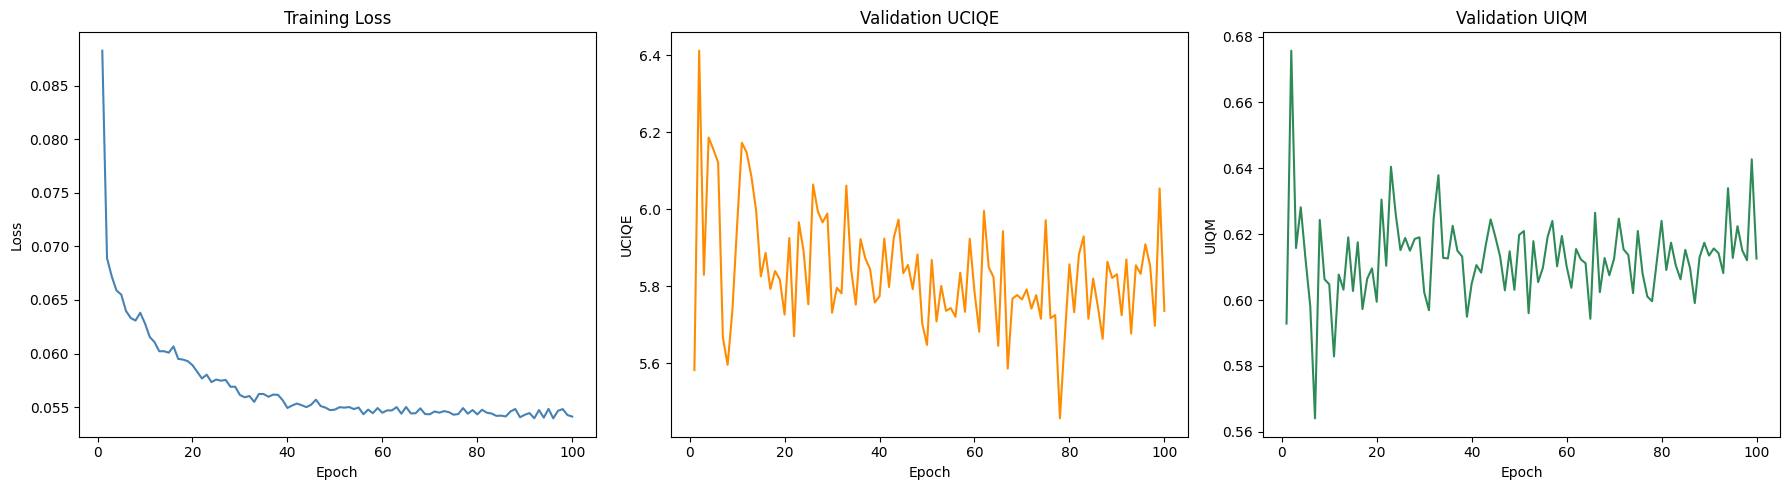

Curves saved to: c:\Users\ASUS\Downloads\Underwater-Image-Enhancement-clean (1)\clean_repo\results\training_curves.png


In [2]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from config import LOGS_DIR, RESULTS_DIR

log_path = Path(LOGS_DIR) / 'train_log.csv'
out_path = Path(RESULTS_DIR) / 'training_curves.png'

if not log_path.exists():
    print('Log file not found. Has training completed?')
else:
    df = pd.read_csv(log_path)
    print(f'Training log loaded: {len(df)} epochs')

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(df['epoch'], df['train_loss'], color='steelblue')
    axes[0].set_title('Training Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')

    axes[1].plot(df['epoch'], df['val_uciqe'], color='darkorange')
    axes[1].set_title('Validation UCIQE')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('UCIQE')

    axes[2].plot(df['epoch'], df['val_uiqm'], color='seagreen')
    axes[2].set_title('Validation UIQM')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('UIQM')

    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f'Curves saved to: {out_path}')


## Run EUVP Evaluation

This evaluates the best checkpoint if present, otherwise falls back to `model_final.pth`.


In [4]:
import subprocess
import sys
from pathlib import Path
from config import CHECKPOINT_BEST, CHECKPOINT_FINAL

best_ckpt = Path(CHECKPOINT_BEST)
final_ckpt = Path(CHECKPOINT_FINAL)
ckpt = best_ckpt if best_ckpt.exists() else final_ckpt

if not ckpt.exists():
    print('No checkpoint found for evaluation.')
else:
    print(f'Using checkpoint: {ckpt}')
    subprocess.run(
        [sys.executable, 'evaluation/eval_euvp.py', '--checkpoint', str(ckpt)],
        check=True,
    )


Using checkpoint: c:\Users\ASUS\Downloads\Underwater-Image-Enhancement-clean (1)\clean_repo\checkpoints\model_best.pth


## Generate Sample Comparisons

This runs batch inference on 8 images and writes comparisons under `results/`.


In [5]:
import subprocess
import sys
from pathlib import Path
from config import CHECKPOINT_BEST, CHECKPOINT_FINAL

best_ckpt = Path(CHECKPOINT_BEST)
final_ckpt = Path(CHECKPOINT_FINAL)
ckpt = best_ckpt if best_ckpt.exists() else final_ckpt

if not ckpt.exists():
    print('No checkpoint found for inference.')
else:
    subprocess.run(
        [
            sys.executable,
            'main.py',
            'infer',
            '--mode', 'batch',
            '--checkpoint', str(ckpt),
            '--limit', '8',
        ],
        check=True,
    )
